In [1]:
from datascience import *
import numpy as np
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Updating Probabilities

Recall: For an Event $E$

$P(E) = \dfrac{\text{chance of E happening}}{\text{all possible outcomes}}$

## Conditional Probabilities

Instead of looking at all possible outcomes, we want to focus on a subset of those outcomes.

$P(\text{A given B has happened}) = P(A|B) = \dfrac{\text{Chance of A happening from the B group}}{\text{Chance of B happening}}$

We will use different scenarios to explore conditional probability. 

### Scenario 1 - A College Class of Students

* Class consists of second years (60%) and third years (40%)
* 50% of the second years have declared their major
* 80% of the third years have declared their major


In [3]:
# Create a table of data using specific attributes of the scenario.
# np.array(list) converts list to an array provided all the elements of list are of the same type.

# Class size of 100 students with the defined percentage of second and third year students. 
n = 100
second = round(n * 0.6)
third = round(n * 0.4)

# Defining how many are declared based on the scenario.

year = np.array(['Second'] * second + ['Third'] * third)
major = np.array(['Declared'] * (round(second * 0.5)) + ['Undeclared'] * (round(second * 0.5)) + 
                 ['Declared'] * (round(third * 0.8))  + ['Undeclared'] * (round(third * 0.2)))
                 
students = Table().with_columns(
    'Year', year,
    'Major', major
)
students

Year,Major
Second,Declared
Second,Declared
Second,Declared
Second,Declared
Second,Declared
Second,Declared
Second,Declared
Second,Declared
Second,Declared
Second,Declared


## Which is More Likely Than Not? ##

Standard probability:

***QUESTION: If we pick one student at random, which is more likely: Second year or Third year?***


What if we ask the question differently?

***QUESTION: If we pick one student at random who has declared their major, is a second or third year more likely?***

This question requires conditional probability. 

***QUESTION: What is the "Condition"?***



In [4]:
students.show(3)

Year,Major
Second,Declared
Second,Declared
Second,Declared


In [5]:
# COMPLETE: Create a pivot table for the major and the year.

students.pivot('Major', 'Year')

Year,Declared,Undeclared
Second,30,30
Third,32,8


In [6]:
# COMPLETE: Verify mathematically 60% of students are Second years using the values from the pivot table. 

(30 + 30) / (30 + 30 + 32 + 8)

0.6

In [7]:
# COMPLETE: Verify mathematically 50% of Second years have Declared using the values from the pivot table. 

30 / 60

0.5

In [8]:
# COMPLETE: Verify mathematically 80% of Third years have Declared using the values from the pivot table. 

32 / 40

0.8

We have verified that we set up our scenario data correctly based on the scenario parameters.

### Conditional Probability

Use the pivot table above to calculate the conditional probabilities below. 

In [9]:
# COMPLETE: Copy the pivot table code here to view it again. 

students.pivot('Major', 'Year')

Year,Declared,Undeclared
Second,30,30
Third,32,8


In [12]:
# COMPLETE: Find the chance of second year, given that they have declared
# P(second year | declared)

30 / 62

0.4838709677419355

In [13]:
# COMPLETE: Find the chance of third year, given that they have declared
# P(third year | declared)

32 / 62

0.5161290322580645

***QUESTION: Which was more likely? Why do you think that is?***



## Tree Diagram Calculation

We can also calculate conditional probability using the paths of a tree diagram.

Review the tree diagram below to see how it matches our scenario.

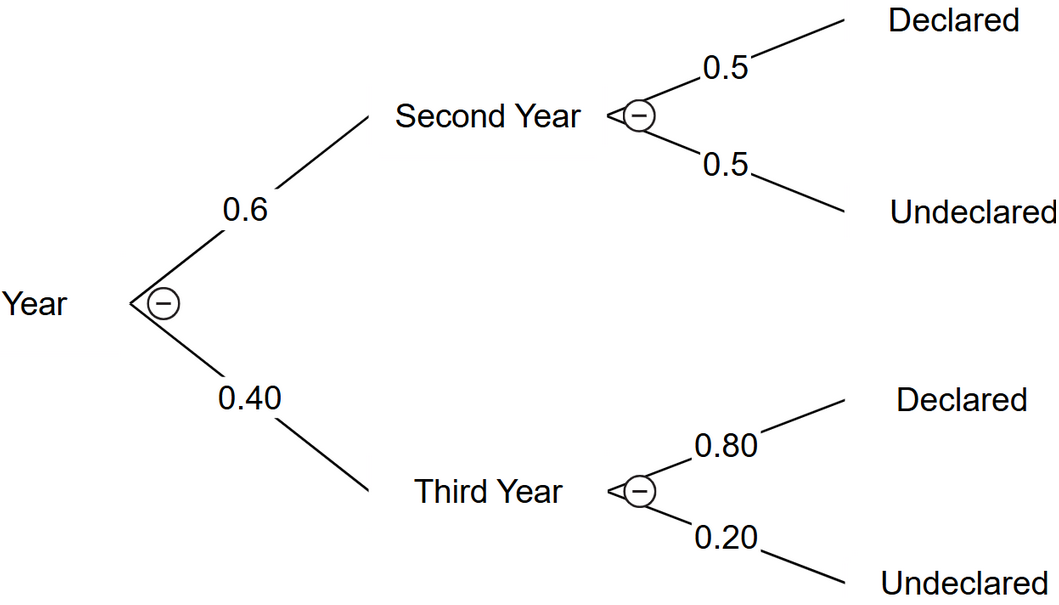

In [12]:
# COMPLETE: Calculate the chance of a second year, given that they have declared from the tree diagram
# P(second year | declared)

(0.6 * 0.5) / (0.6 * 0.5 + 0.4 * 0.8)

0.4838709677419354

***QUESTION: Does this calculation give the same result as your calulation above?***

### Scenario 2 - A Disease in the Population ###

Testing for a disease k% of the population studied has the disease.
* False positive is 5%
* False negative is 0%

In [16]:
# Creates a function that returns the pivot table for the results of a test after creating a data set following particular attributes.

def create_population(prior_disease_prob, n):
    disease = round(n * prior_disease_prob)
    no_disease = round(n * (1 - prior_disease_prob))

    status = np.array(['Disease'] * disease  +  ['No disease'] * no_disease)
    result = np.array(['Test +'] * (disease) + ['Test +'] * (round(no_disease * 0.05))  + \
                 ['Test -'] * (round(no_disease * 0.95)))
                 
    t = Table().with_columns(
    'Status', status,
    'Test Result', result
    )
    return t.pivot('Test Result', 'Status')


#### Population 1: ####

Use the create_population function, defined above, to create a population that has  
* a 1/1000 chance of getting a disease
* with an $n$ of 10000

In [19]:
# COMPLETE: Use the create population function to define the scenario above.

create_population(1/1000, 10000)

Status,Test +,Test -
Disease,10,0
No disease,500,9490


In [20]:
# COMPLETE: Find the probability that someone who test positive has the disease.
# P(Has Disease|Test Positive)

10 / 510

0.0196078431372549

### Baye's Rule for conditional probability

Purpose of Baye's Rule is to update your prediction based on new information.

In a multi-stage experiment, find the chance of an event at an earlier stage, given the result of a later stage.

$P(A|B) = \dfrac{P(B|A)\cdot P(A)}{P(B)}$

Typically used for more complicated scenarios, but we will use it to see how it works. 



In [21]:
# COMPLETE: Using the same defined population above, evaluate each term of the function then combine for Baye's Rule.  
# Baye's Rule:  P(disease | tested +)  = (P(tested +|disease) * P(disease)) / P(tested +)

p_a  = 10 / 10000 # prob has disease
p_b  = 510 / 10000 # prob tested positive
p_ba = 10 / 10 # prob tested positive given they have the disease

(p_a * p_ba) / p_b

0.019607843137254905

In [23]:
# COMPLETE: Using the same defined population above, evaluate using the tree diagram below: 
# P(disease | tested +)  = P(disease & tested +) / P(tested +)

k = 1 / 1000
(k * 1) / (k * 1 + (1 - k) * 0.05)

0.019627085377821395

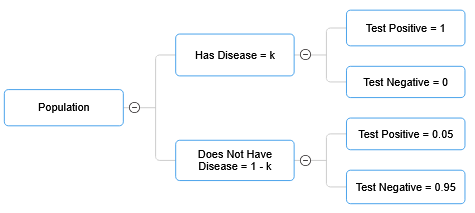

***QUESTION: What do you notice when comparing the results from the three different calculation methods?***

#### Population 2: ####

Use the create_population function, defined above, to create a population that has  

* a 1/10 chance of getting a disease
* with an $n$ of 10000

In [24]:
# COMPLETE: Use the create population function to define the scenario above.

create_population(1/10, 10000)

Status,Test +,Test -
Disease,1000,0
No disease,450,8550


In [25]:
# COMPLETE: Use the Pivot Table to mathematically compute the Conditional
# P(disease | tested +)

1000 / 1450

0.6896551724137931

In [26]:
# COMPLETE: Use Baye's Rule
# Baye's Rule:  P(disease | tested +)  = (P(tested +|disease) * P(disease)) / P(tested +)

p_a = 1000 / 10000 # prob has disease
p_b = 1450 / 10000 # prob tested positive
p_ba = 1000 / 1000 # prob tested positive given they have the disease

(p_a * p_ba) / p_b

0.6896551724137931

In [27]:
# COMPLETE: Evaluate using the tree diagram above: 
# P(disease | tested +)  = P(disease & tested +) / P(tested +)

(0.1 * 1) / (0.1 * 1 + 0.9 * 0.05)

0.689655172413793

#### Population 3: ####
One more population: 
* a 1/2 chance of getting a disease
* with an $n$ of 10000

In [28]:
# Creating the popultion.

create_population(0.5, 10000)

Status,Test +,Test -
Disease,5000,0
No disease,250,4750


In [25]:
# Baye's Rule:  P(disease | tested +)  = (P(tested +|disease) * P(disease)) / P(tested +)

p_a = 5000 / 10000 #prob has disease
p_b = 5250 / 10000 #prob tested positive
p_ba = 5000 / 5000 #prob tested positive given they have the disease

(p_a * p_ba) / p_b


0.9523809523809523

In [29]:
# Using the tree diagram above: 
# P(disease | tested +)  = P(disease & tested +) / P(tested +)

(0.5 * 1) / (0.5 * 1 + 0.5 * 0.05)

0.9523809523809523

In [27]:
# COMPLETE: Use the Pivot Table to mathematically compute the Conditional
# P(disease | tested +)

5000 / 5250

0.9523809523809523